# **P**anatopic **A**dversarial **N**uclei **C**lassification **a**nd **K**nowledge-**E**nhanced **S**egmentation using Pathopix-GANs
Dataset Structure
The dataset is organized into three folds: fold1, fold2, and fold3, consistent with the original dataset structure. Each fold contains data in a tabular format with the following four columns:

image: The RGB tile of the sample.
instances: A list of nuclei instances. Each instance represents exactly one nucleus and is in binary format (1 - nucleus, 0 - background)
categories: An integer class label for each nucleus, corresponding to one of the following categories:

1. Neoplastic
2. Inflammatory
3. Connective
4. Dead
5. Epithelial

tissue: The integer tissue type from which the sample originates, belonging to one of these categories:

1. Adrenal Gland
2. Bile Duct
3. Bladder
4. Breast
5. Cervix
6. Colon
7. Esophagus
8. Head & Neck
9. Kidney
10. Liver
11. Lung
12. Ovarian
13. Pancreatic
14. Prostate
15. Skin
16. Stomach
17. Testis
18. Thyroid
19. Uterus

### **Setting up Ultralytics for Inference**

In [28]:
%%capture
%pip install "ultralytics<=8.3.40" supervision roboflow

In [6]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO
from pathlib import Path
import random
import os
import re

### **Inference**


0: 640x640 35 1s, 469.2ms
Speed: 3.0ms preprocess, 469.2ms inference, 71.9ms postprocess per image at shape (1, 3, 640, 640)


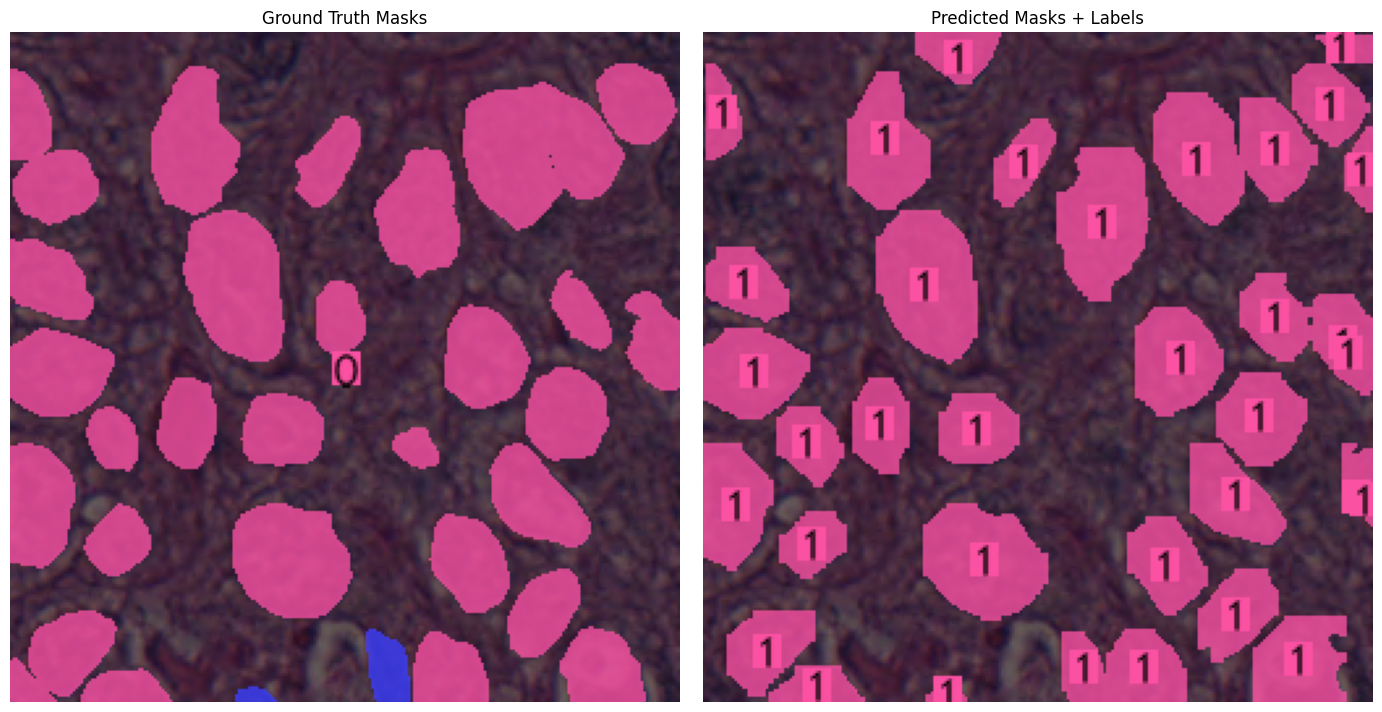


0: 640x640 1 2, 1 3, 457.0ms
Speed: 3.8ms preprocess, 457.0ms inference, 17.7ms postprocess per image at shape (1, 3, 640, 640)


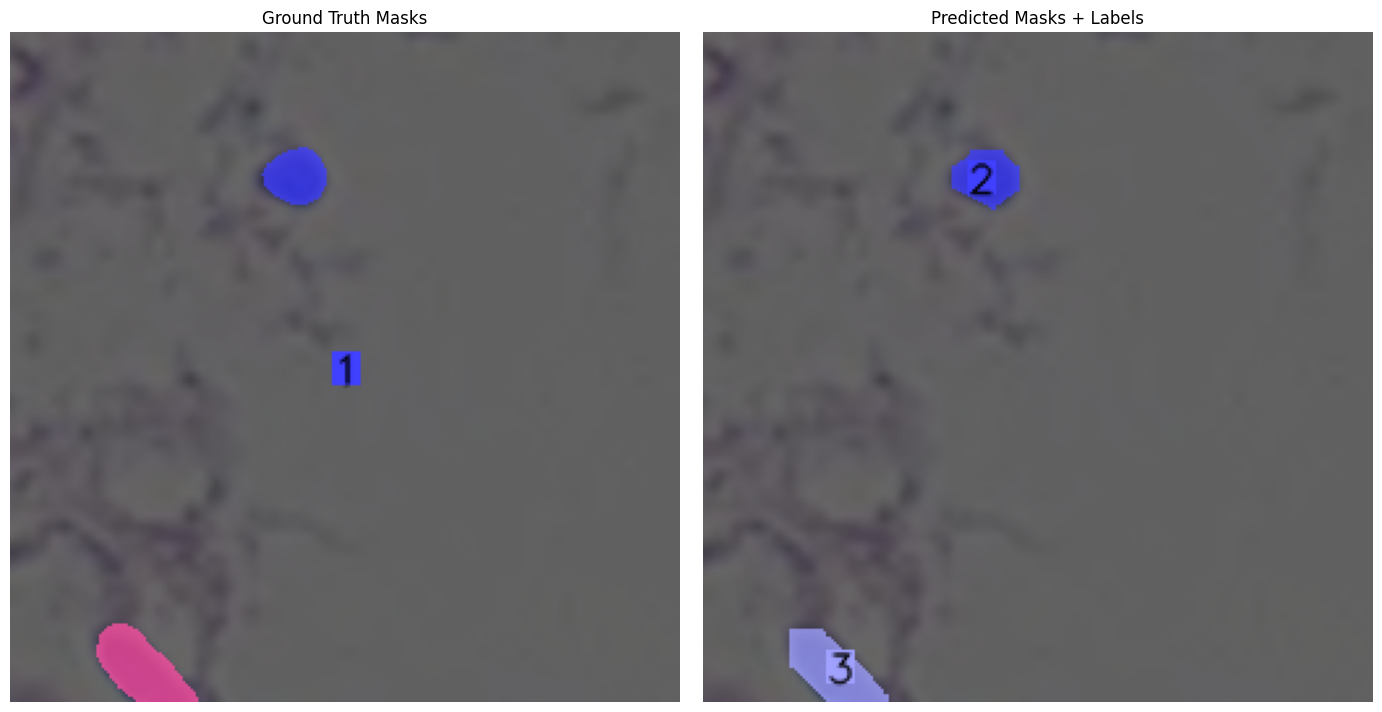


0: 640x640 27 1s, 2 2s, 455.0ms
Speed: 3.2ms preprocess, 455.0ms inference, 73.7ms postprocess per image at shape (1, 3, 640, 640)


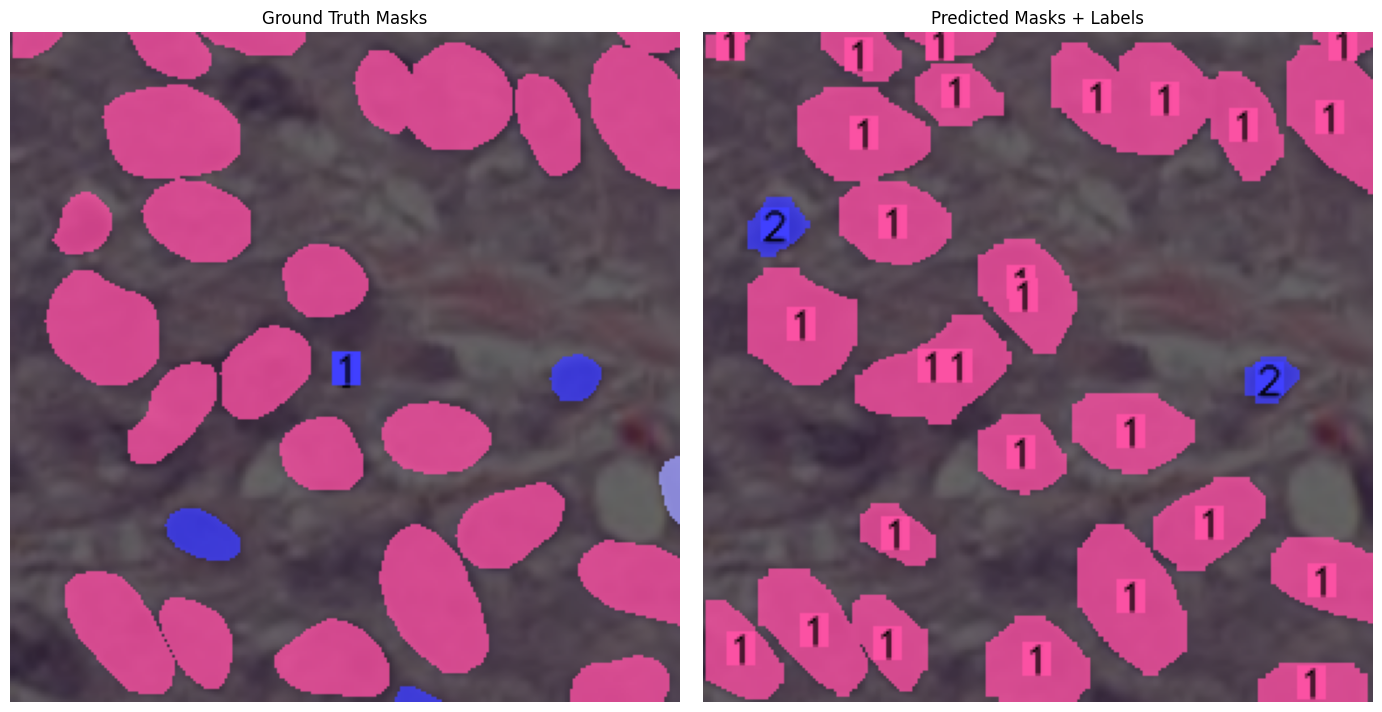

In [27]:
dataset_path = Path("/kaggle/input/pannuke/dataset/fold_1")
model_path = "/kaggle/input/pancakes-yolo11/other/default/1/best.pt"

model = YOLO(model_path)

def load_and_display_sample(sample_dir):
    image_path = sample_dir / "image.png"
    mask_dir = sample_dir / "masks"

    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image).astype(np.float32) / 255.0
    dimmed_image_np = image_np * 0.4  
    dimmed_image = (dimmed_image_np * 255).astype(np.uint8)

    masks = []
    class_ids = []
    category_to_class_id = {}
    current_class_id = 0

    for mask_file in os.listdir(mask_dir):
        if mask_file.endswith(".png"):

            match = re.match(r"mask_(\d+)_\d+\.png", mask_file)
            if match:
                category = match.group(1)
                if category not in category_to_class_id:
                    category_to_class_id[category] = current_class_id
                    current_class_id += 1
                class_id = category_to_class_id[category]

                mask = Image.open(mask_dir / mask_file).convert("L")
                mask_array = np.array(mask) > 0  

                masks.append(mask_array)
                class_ids.append(class_id)

    image_width, image_height = image.size

    xyxy = np.array([[0, 0, image_width, image_height]] * len(masks))

    detections = sv.Detections(
        xyxy=xyxy,
        mask=np.array(masks),
        class_id=np.array(class_ids)
    )

    mask_annotator = sv.MaskAnnotator(opacity=0.8, color_lookup=sv.ColorLookup.CLASS)
    label_annotator = sv.LabelAnnotator(
        text_color=sv.Color.BLACK,
        text_position=sv.Position.CENTER,
        text_padding=0
    )
    gt_overlay = mask_annotator.annotate(scene=dimmed_image.copy(), detections=detections)
    gt_overlay = label_annotator.annotate(scene=gt_overlay, detections=detections)

    result = model.predict(image, conf=0.25)[0]
    pred_detections = sv.Detections.from_ultralytics(result)

    pred_mask_annotator = sv.MaskAnnotator(opacity=0.8)
    pred_label_annotator = sv.LabelAnnotator(
        text_color=sv.Color.BLACK,
        text_position=sv.Position.CENTER,
        text_padding=0
    )
    pred_overlay = pred_mask_annotator.annotate(scene=dimmed_image.copy(), detections=pred_detections)
    pred_overlay = pred_label_annotator.annotate(scene=pred_overlay, detections=pred_detections)

    fig, axs = plt.subplots(1, 2, figsize=(14, 7))
    axs[0].imshow(gt_overlay)
    axs[0].set_title("Ground Truth Masks")
    axs[0].axis("off")

    axs[1].imshow(pred_overlay)
    axs[1].set_title("Predicted Masks + Labels")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

sample_dirs = [f for f in dataset_path.iterdir() if f.is_dir()]
random_samples = random.sample(sample_dirs, 3)

for sample in random_samples:
    load_and_display_sample(sample)